# URMA Student ANN-SNN Bootstrap Conversion

This notebook adapts the Lava bootstrap MNIST tutorial to the URMA teacher-student policy setting. Instead of image classification, the task is continuous action regression: observations from the teacher/student DAgger dataset are mapped to 24-dimensional robot actions.

The starting point is the trained ANN student checkpoint in this folder. A Lava bootstrap student is initialized from that ANN, trained against the teacher actions, evaluated in both ANN and SNN modes, then exported as an HDF5 Lava network.

In [1]:
from pathlib import Path
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

from train_student import load_student_model_from_checkpoint
from bootstrap_backend import (
    BootstrapTrainingConfig,
    BootstrapStudentTrainer,
    collect_bootstrap_activity_stats,
    evaluate_ann_bootstrap_parity,
    evaluate_bootstrap_against_teacher,
    load_bootstrap_policy_from_checkpoint,
    load_teacher_dataset,
    resolve_bootstrap_device,
)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration

The default sample counts keep the notebook responsive. Increase `MAX_TRAIN_SAMPLES`, `EVAL_SAMPLES`, and `EPOCHS` for a production conversion run.

In [2]:
NOTEBOOK_DIR = Path.cwd()
DATASET_PATH = NOTEBOOK_DIR / "teacher_student_dagger_dataset.npz"
ANN_CHECKPOINT_PATH = NOTEBOOK_DIR / "student_model_latest.pth"
OUTPUT_DIR = NOTEBOOK_DIR / "Trained"
OUTPUT_DIR.mkdir(exist_ok=True)

DEVICE = resolve_bootstrap_device("cuda" if torch.cuda.is_available() else "cpu")
MAX_TRAIN_SAMPLES = 50_000
EVAL_SAMPLES = 2_048
BATCH_SIZE = 64
EPOCHS = 10
TIMESTEPS = 3
READOUT = "mean"

print(f"device: {DEVICE}")
print(f"dataset: {DATASET_PATH}")
print(f"ann checkpoint: {ANN_CHECKPOINT_PATH}")

device: cuda
dataset: /app/lava-dl/tutorials/lava/lib/dl/bootstrap/urma/teacher_student_dagger_dataset.npz
ann checkpoint: /app/lava-dl/tutorials/lava/lib/dl/bootstrap/urma/student_model_latest.pth


# Load the Teacher-Student Dataset and ANN Student

The dataset contains teacher observations and actions saved from the URMA DAgger pipeline. The ANN checkpoint provides the architecture and weights used to initialize the bootstrap SNN student.

In [4]:
states, teacher_actions = load_teacher_dataset(DATASET_PATH, max_samples=MAX_TRAIN_SAMPLES)
eval_states, eval_teacher_actions = load_teacher_dataset(DATASET_PATH, max_samples=EVAL_SAMPLES)
ann_student, ann_architecture = load_student_model_from_checkpoint(ANN_CHECKPOINT_PATH, device=DEVICE)

print("train states:", tuple(states.shape))
print("train actions:", tuple(teacher_actions.shape))
print("eval states:", tuple(eval_states.shape))
print("ANN architecture:", ann_architecture)

train states: (50000, 668)
train actions: (50000, 24)
eval states: (2048, 668)
ANN architecture: {'input_dim': 668, 'output_dim': 24, 'hidden_dims': [1024, 1024, 1024, 1024, 1024]}


In [5]:
with torch.no_grad():
    ann_actions = ann_student(eval_states.to(DEVICE)).detach().cpu()

ann_error = torch.linalg.norm(ann_actions - eval_teacher_actions, dim=1) / torch.linalg.norm(eval_teacher_actions, dim=1).clamp_min(1e-8)
print(f"ANN teacher mean percentage error: {100.0 * ann_error.mean().item():.4f}%")
print(f"ANN teacher median percentage error: {100.0 * ann_error.median().item():.4f}%")

ANN teacher mean percentage error: 2.7046%
ANN teacher median percentage error: 2.1434%


# Train the Lava Bootstrap Student

Bootstrap training alternates through sampling, fitting, ANN, and SNN modes using `lava.lib.dl.bootstrap.routine.Scheduler`. The first bootstrap layer uses signed-split encoding so real-valued positive and negative observation channels can drive nonnegative spike inputs.

In [6]:
bootstrap_config = BootstrapTrainingConfig(
    dataset_path=str(DATASET_PATH),
    batch_size=BATCH_SIZE,
    learning_rate=1e-4,
    epochs=EPOCHS,
    hidden_dims=ann_architecture["hidden_dims"],
    val_split=0.2,
    checkpoint_dir=str(OUTPUT_DIR),
    best_checkpoint_name="bootstrap_student_best.pth",
    latest_checkpoint_name="bootstrap_student_latest.pth",
    timesteps=TIMESTEPS,
    readout=READOUT,
    num_sample_iter=10,
    sample_period=10,
    neuron_threshold=1.0,
    current_decay=0.25,
    voltage_decay=0.03,
    weight_scale=1.0,
    weight_norm=False,
    input_strategy="signed_split",
    input_weight=1.0,
    input_bias=0.0,
    initialize_from_ann=True,
)

trainer = BootstrapStudentTrainer(config=bootstrap_config, device=DEVICE)
artifacts = trainer.train_on_arrays(
    states=states,
    actions=teacher_actions,
    initialize_from_ann=ann_student,
)
bootstrap_student = trainer.model

print(artifacts)

TrainingArtifacts(best_val_loss=0.29273410862798144, best_checkpoint_path='/app/lava-dl/tutorials/lava/lib/dl/bootstrap/urma/Trained/bootstrap_student_best.pth', latest_checkpoint_path='/app/lava-dl/tutorials/lava/lib/dl/bootstrap/urma/Trained/bootstrap_student_latest.pth', last_train_loss=0.002575421253964305, last_val_loss=0.2935578213755492, iteration_checkpoint_path=None)


# Evaluate ANN-SNN Parity and Teacher Error

Parity compares the trained ANN student with the bootstrap model running in SNN mode. Teacher error compares both models against the teacher action targets.

In [7]:
bootstrap_student.eval()

parity = evaluate_ann_bootstrap_parity(
    student_model=ann_student,
    bootstrap_model=bootstrap_student,
    states=eval_states,
    batch_size=BATCH_SIZE,
    device=DEVICE,
)
teacher_metrics = evaluate_bootstrap_against_teacher(
    student_model=ann_student,
    bootstrap_model=bootstrap_student,
    states=eval_states,
    teacher_actions=eval_teacher_actions,
    batch_size=BATCH_SIZE,
    device=DEVICE,
)
activity = collect_bootstrap_activity_stats(
    bootstrap_model=bootstrap_student,
    states=eval_states[: min(256, len(eval_states))],
    device=DEVICE,
)

print(json.dumps({"parity": parity, "teacher": teacher_metrics, "activity": activity}, indent=2))

{
  "parity": {
    "selected_readout": "mean",
    "samples": 2048,
    "relative_l2_error": 1.0003177982946339,
    "mae": 0.3095426894724369,
    "output_scale_ratio": 0.013646176137783536,
    "readout_diagnostics": {
      "mean": {
        "relative_l2_error": 1.0003177982946339,
        "mae": 0.3095426894724369,
        "output_scale_ratio": 0.013646176137783536
      },
      "last": {
        "relative_l2_error": 1.007637122337204,
        "mae": 0.31246272039910156,
        "output_scale_ratio": 0.04093852766107319
      },
      "sum": {
        "relative_l2_error": 1.007637122337204,
        "mae": 0.31246272039910156,
        "output_scale_ratio": 0.04093852766107319
      }
    }
  },
  "teacher": {
    "student_mean_percentage_error": 2.704599380493164,
    "student_median_percentage_error": 2.1434388160705566,
    "snn_mean_percentage_error": 100.10413360595703,
    "snn_median_percentage_error": 100.0
  },
  "activity": {
    "input_strategy": "signed_split",
    "enc

# Visualize Action Errors

The plot compares per-action mean absolute error for the ANN student and the bootstrap SNN on the evaluation slice.

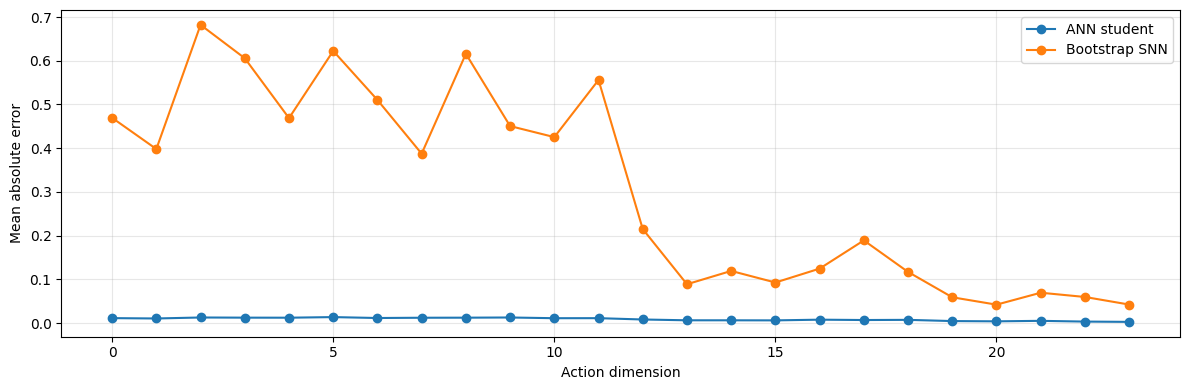

In [8]:
with torch.no_grad():
    ann_eval_actions = ann_student(eval_states.to(DEVICE)).detach().cpu()
bootstrap_eval_actions = torch.from_numpy(bootstrap_student.predict(eval_states.numpy(), readout=READOUT)).float()

ann_mae_by_dim = (ann_eval_actions - eval_teacher_actions).abs().mean(dim=0).numpy()
bootstrap_mae_by_dim = (bootstrap_eval_actions - eval_teacher_actions).abs().mean(dim=0).numpy()

action_index = np.arange(eval_teacher_actions.shape[1])
plt.figure(figsize=(12, 4))
plt.plot(action_index, ann_mae_by_dim, marker="o", label="ANN student")
plt.plot(action_index, bootstrap_mae_by_dim, marker="o", label="Bootstrap SNN")
plt.xlabel("Action dimension")
plt.ylabel("Mean absolute error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Export the Bootstrap SNN

The exported HDF5 network mirrors the MNIST tutorial export path and can be loaded by Lava tooling that consumes bootstrap block exports.

In [8]:
def export_bootstrap_hdf5(model, filename):
    filename = Path(filename)
    filename.parent.mkdir(parents=True, exist_ok=True)
    with h5py.File(filename, "w") as h5_file:
        simulation = h5_file.create_group("simulation")
        simulation["Ts"] = 1
        simulation["tSample"] = model.timesteps
        layer = h5_file.create_group("layer")
        for index, block in enumerate(model.blocks):
            block.export_hdf5(layer.create_group(f"{index}"))
    return filename

best_bootstrap, best_architecture = load_bootstrap_policy_from_checkpoint(
    artifacts.best_checkpoint_path,
    device=DEVICE,
)
export_path = export_bootstrap_hdf5(best_bootstrap, OUTPUT_DIR / "bootstrap_student.net")
print(f"exported: {export_path}")
print("bootstrap architecture:", best_architecture)

TypeError: Object dtype dtype('O') has no native HDF5 equivalent